# Kruskal-Wallis H Test

Non-parametric test to determine whether there are statistically significant differences between groups.

## 1. Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_excel("../../data/processed/EGFR_combined.xlsx")

print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst rows:")
df.head(10)

Shape: (1, 17)

Data types:
Gruppe                                       str
Sample                                       str
Name                                         str
TPM                                      float64
RPKM                                     float64
Unique gene reads                          int64
Total gene reads                           int64
Transcripts annotated                      int64
Uniquely identified transcripts            int64
Unique exon reads                          int64
Total exon reads                           int64
Ratio of unique to total (exon reads)    float64
Unique exon-exon reads                     int64
Total exon-exon reads                      int64
Unique intron reads                        int64
Total intron reads                         int64
Ratio of intron to total gene reads      float64
dtype: object

First rows:


,Gruppe,Sample,Name,TPM,RPKM,Unique gene reads,Total gene reads,Transcripts annotated,Uniquely identified transcripts,Unique exon reads,Total exon reads,Ratio of unique to total (exon reads),Unique exon-exon reads,Total exon-exon reads,Unique intron reads,Total intron reads,Ratio of intron to total gene reads
0,A,R22103005-1016330242_S10,EGFR,176901.202317,19558.96273,732206,735431,11,9,478885,482094,0.993344,332864,332890,253321,253337,0.344474


## 2. Variable Identification

In [4]:
group_col = "Gruppe"
dependent_col = "TPM"

print(f"Grouping variable: {group_col}")
print(f"Dependent variable: {dependent_col}")
print(f"\nUnique groups: {df[group_col].unique()}")
print(f"Number of groups: {df[group_col].nunique()}")
print(f"\nSample sizes per group:")
print(df[group_col].value_counts().sort_index())
print(f"\nDescriptive statistics per group:")
df.groupby(group_col)[dependent_col].describe()

Grouping variable: Gruppe
Dependent variable: TPM

Unique groups: <StringArray>
['A']
Length: 1, dtype: str
Number of groups: 1

Sample sizes per group:
Gruppe
A    1
Name: count, dtype: int64

Descriptive statistics per group:


,count,mean,std,min,25%,50%,75%,max
Gruppe,,,,,,,,
A,1.0,176901.202317,NaN,176901.202317,176901.202317,176901.202317,176901.202317,176901.202317


## 3. Assumption Checks

The Kruskal-Wallis test requires:
1. **Independent observations** — each observation belongs to only one group.
2. **Ordinal or continuous dependent variable.**
3. **Similar distribution shapes** across groups (not identical, but similar shape so that differences reflect location shifts).

Duplicate rows: 0
=> Observations assumed independent (one measurement per subject per group).

Dependent variable 'TPM' dtype: float64
=> Continuous variable — assumption satisfied.


C:\Users\Nico\miniconda3\Lib\site-packages\scipy\stats\_morestats.py:676: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r, prob, _ = _stats_py.linregress(osm, osr)


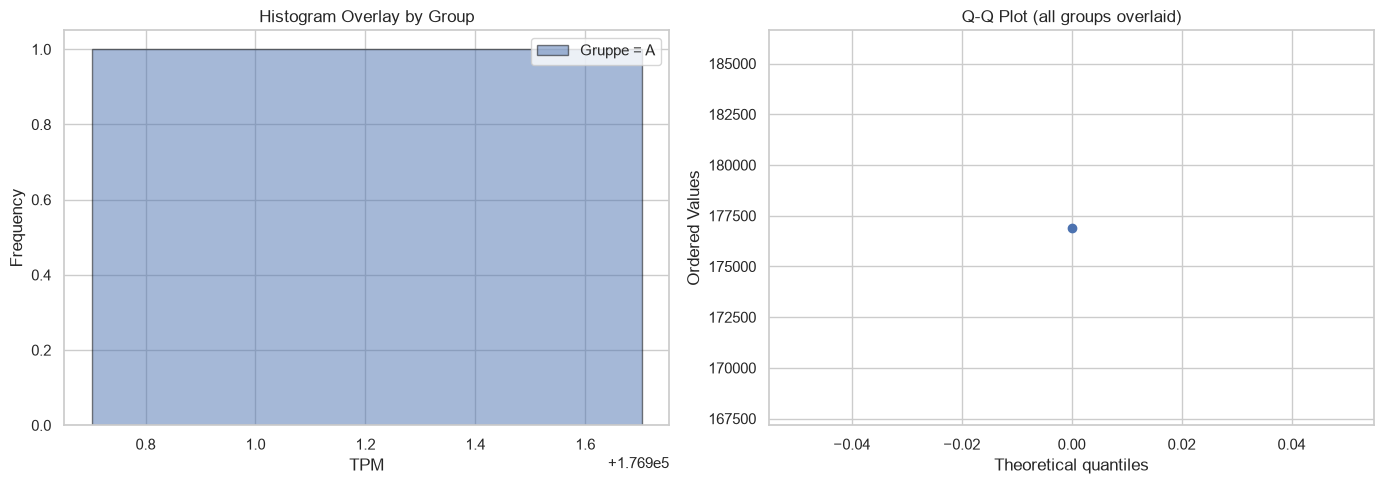


Visual inspection: if histograms show roughly similar shapes (not necessarily
normal), the assumption of similar distributions is reasonable.


In [5]:
from pathlib import Path

groups = df[group_col].unique()
n_groups = len(groups)

# Check 1: Independent observations
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")
print("=> Observations assumed independent (one measurement per subject per group).")

# Check 2: Dependent variable type
print(f"\nDependent variable '{dependent_col}' dtype: {df[dependent_col].dtype}")
print("=> Continuous variable — assumption satisfied.")

# Check 3: Similar distribution shapes — histogram overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram overlay
for g in sorted(groups):
    subset = df.loc[df[group_col] == g, dependent_col].dropna()
    axes[0].hist(subset, alpha=0.5, label=f"{group_col} = {g}", bins="auto", edgecolor="black")
axes[0].set_xlabel(dependent_col)
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram Overlay by Group")
axes[0].legend()

# QQ plots per group
for g in sorted(groups):
    subset = df.loc[df[group_col] == g, dependent_col].dropna()
    stats.probplot(subset, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (all groups overlaid)")

plt.tight_layout()
Path("../../figures/TPM/assumption_checks.png").mkdir(parents=True, exist_ok=True)
fig.savefig("../../figures/TPM/assumption_checks.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nVisual inspection: if histograms show roughly similar shapes (not necessarily")
print("normal), the assumption of similar distributions is reasonable.")

## 4. Kruskal-Wallis Test

In [8]:
group_data = [group[dependent_col].dropna().values for _, group in df.groupby(group_col)]

H_stat, p_value = stats.kruskal(*group_data)
dof = n_groups - 1

print("=" * 50)
print("       Kruskal-Wallis H Test Results")
print("=" * 50)
print(f"  H-statistic : {H_stat:.4f}")
print(f"  Degrees of freedom : {dof}")
print(f"  p-value     : {p_value:.6f}")
print("=" * 50)

alpha = 0.05
if p_value < alpha:
    print(f"\n=> Result is SIGNIFICANT at α = {alpha}.")
    print("   At least one group differs significantly from the others.")
else:
    print(f"\n=> Result is NOT significant at α = {alpha}.")
    print("   No significant differences detected between groups.")

ValueError: Need at least two groups in stats.kruskal()

## 5. Post-Hoc Testing (Dunn's Test)

In [7]:
if p_value < alpha:
    print("Kruskal-Wallis was significant — running Dunn's test with Bonferroni correction.\n")
    dunn_results = sp.posthoc_dunn(df, val_col=dependent_col, group_col=group_col, p_adjust="bonferroni")
    print("Pairwise p-values (Bonferroni-corrected):")
    display(dunn_results.style.map(
        lambda v: "background-color: #ffcccc" if v < alpha else ""
    ))
else:
    print("Kruskal-Wallis was not significant — post-hoc testing is not warranted.")

NameError: name 'p_value' is not defined

## 6. Visualization

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
sns.boxplot(data=df, x=group_col, y=dependent_col, ax=axes[0], palette="Set2")
axes[0].set_title(f"Box Plot of {dependent_col} by {group_col}")
axes[0].set_xlabel(group_col)
axes[0].set_ylabel(dependent_col)

# Violin plot
sns.violinplot(data=df, x=group_col, y=dependent_col, ax=axes[1], palette="Set2", inner="quartile")
axes[1].set_title(f"Violin Plot of {dependent_col} by {group_col}")
axes[1].set_xlabel(group_col)
axes[1].set_ylabel(dependent_col)

fig.suptitle(f"Distribution of {dependent_col} across {group_col} Groups", fontsize=14, y=1.02)
plt.tight_layout()
Path("../../figures/TPM/box_violin_plots.png").mkdir(parents=True, exist_ok=True)
fig.savefig("../../figures/TPM/box_violin_plots.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Summary

**Interpretation:**

A Kruskal-Wallis H test was conducted to determine whether there are statistically significant differences in **TPM** across the levels of **Gruppe**.

- If the p-value is **below 0.05**, we conclude that at least one group's distribution of TPM differs significantly from the others. Dunn's post-hoc test (with Bonferroni correction) identifies which specific group pairs differ.
- If the p-value is **above 0.05**, we fail to reject the null hypothesis — there is no sufficient evidence that TPM distributions differ across groups.

The Kruskal-Wallis test is appropriate here because it does not assume normality, making it suitable for skewed data or data with outliers. The test compares rank-transformed values across groups rather than raw means.